# 07 - Análisis Exploratorio Financiero (EDA Financiero)

## Introducción

Este notebook asume como válidas las etapas previas de adquisición, integración y construcción de variables realizadas en el proyecto.

Por lo tanto, el foco del análisis ya no se encuentra en la validación estructural de los datos, sino en la exploración de comportamientos, patrones, distribuciones, eventos extremos y relaciones observadas entre BTC, DXY, Oro y VIX durante el período analizado.

Las asociaciones identificadas en este notebook deben interpretarse como observaciones descriptivas de los datos y no como evidencia de relaciones causales entre los activos estudiados.

# 1. Objetivo

El objetivo de este notebook es realizar un análisis exploratorio financiero sobre BTC, DXY, Oro y VIX utilizando el dataset integrado generado previamente.

A diferencia de los notebooks anteriores, centrados en validación e integración de datos, este análisis busca identificar patrones de mercado, comportamientos extremos, relaciones entre activos y posibles regímenes financieros presentes durante el período estudiado.

Los hallazgos obtenidos servirán para complementar la interpretación económica del proyecto y aportar contexto a las etapas posteriores de modelado.

# 2. Librerías y configuración

Se importan las librerías necesarias para cargar, transformar y visualizar el dataset integrado utilizado en el análisis financiero.

In [1]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_PATH = r"C:\DS2_BTC_DXY_ORO_VIX"

dataset_path = os.path.join(
    PROJECT_PATH,
    "data",
    "processed",
    "dataset_integrado.csv"
)

# 3. Carga del dataset integrado

Se carga el dataset integrado generado en el Notebook 05, que contiene las series temporales alineadas de BTC, DXY, Oro y VIX.

Este dataset será utilizado como base para el análisis exploratorio financiero.

In [2]:
integrated_df = pd.read_csv(
    dataset_path,
    index_col=0,
    parse_dates=True
)

print("=== DATASET INTEGRADO CARGADO ===")
print(f"Shape: {integrated_df.shape}")
print(f"Rango temporal: {integrated_df.index.min().date()} → {integrated_df.index.max().date()}")

=== DATASET INTEGRADO CARGADO ===
Shape: (752, 32)
Rango temporal: 2023-05-08 → 2026-05-06


# 4. Distribución de retornos de BTC

Se analiza la distribución de los retornos diarios de BTC con el objetivo de comprender su comportamiento general, dispersión y presencia de eventos extremos.

Este análisis permite contextualizar el nivel de riesgo y volatilidad del activo antes de estudiar sus relaciones con otros mercados.

In [3]:
print("=== RESUMEN ESTADÍSTICO BTC_RETURN ===")
print()

print(
    integrated_df["btc_return"].describe()
)

=== RESUMEN ESTADÍSTICO BTC_RETURN ===

count    752.000000
mean       0.001648
std        0.027461
min       -0.141299
25%       -0.013423
50%        0.000369
75%        0.015354
max        0.125248
Name: btc_return, dtype: float64


## 4.1 Histograma de retornos de BTC

Se visualiza la distribución de los retornos diarios de BTC mediante un histograma.

Esta representación permite identificar la concentración de observaciones, la presencia de eventos extremos y posibles desviaciones respecto de una distribución normal.

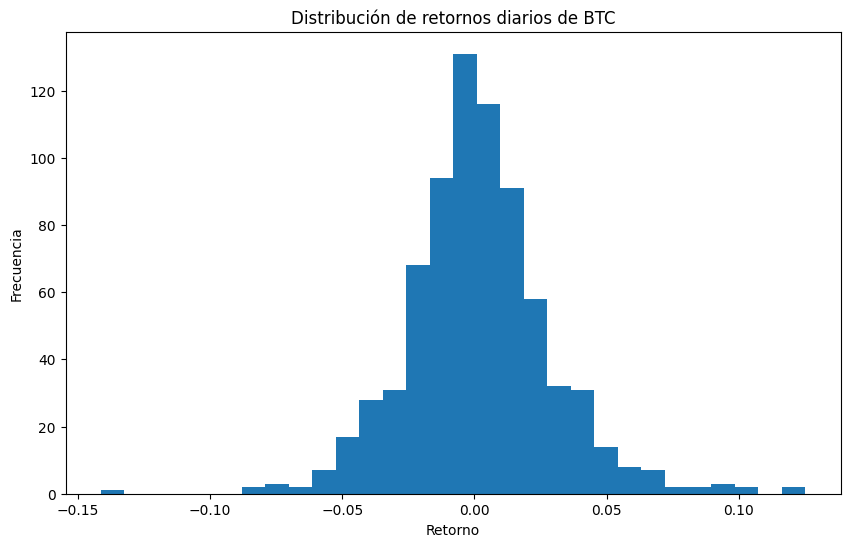

In [4]:
plt.figure(figsize=(10,6))

plt.hist(
    integrated_df["btc_return"],
    bins=30
)

plt.title("Distribución de retornos diarios de BTC")
plt.xlabel("Retorno")
plt.ylabel("Frecuencia")

plt.show()

### 4.1 Conclusiones

El histograma muestra que los retornos diarios de BTC se concentran principalmente alrededor de cero, indicando que la mayor parte de las observaciones corresponden a movimientos diarios relativamente moderados.

Sin embargo, la distribución presenta colas pronunciadas tanto en valores positivos como negativos, evidenciando la existencia de eventos extremos que se alejan significativamente del comportamiento habitual del activo.

Estos resultados son consistentes con las características observadas previamente en el resumen estadístico y refuerzan la naturaleza altamente volátil de BTC durante el período analizado.

## 4.2 Boxplot de retornos de BTC

Se utiliza un boxplot para visualizar la dispersión de los retornos diarios de BTC e identificar la presencia de observaciones extremas.

Esta representación complementa el histograma al resumir la distribución mediante mediana, rango intercuartílico y posibles outliers.

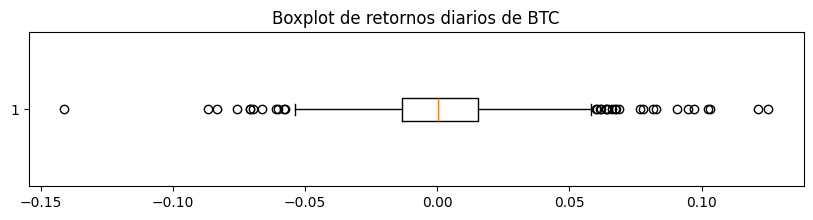

In [5]:
plt.figure(figsize=(10, 2))

plt.boxplot(
    integrated_df["btc_return"].dropna(),
    vert=False
)

plt.title("Boxplot de retornos diarios de BTC")

plt.show()

### 4.2 Conclusiones

El boxplot confirma que la mayor parte de los retornos diarios de BTC se concentra dentro de un rango relativamente acotado alrededor de cero.

Sin embargo, se observan numerosos valores atípicos tanto positivos como negativos, evidenciando la presencia recurrente de movimientos extremos durante el período analizado.

Estos resultados son consistentes con el histograma y el resumen estadístico previamente presentados, reforzando la idea de que BTC combina períodos de comportamiento relativamente estable con episodios de alta volatilidad y cambios bruscos de precio.

## 4.3 Comparación de distribuciones de retornos

Se comparan las distribuciones de retornos diarios de BTC, DXY, Oro y VIX mediante boxplots.

Esta visualización permite evaluar diferencias en dispersión, volatilidad y presencia de valores extremos entre los distintos activos analizados.

C:\Users\amilc\AppData\Local\Temp\ipykernel_1460\1217946550.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


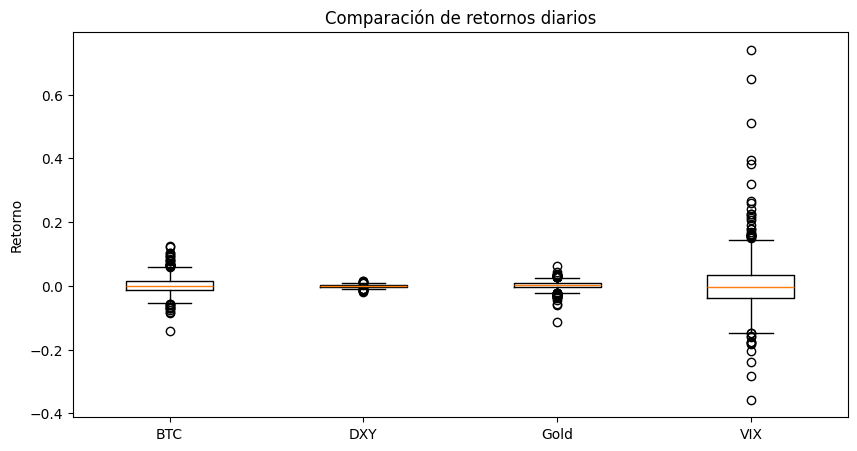

In [6]:
returns_df = integrated_df[
    [
        "btc_return",
        "dxy_return",
        "gold_return",
        "vix_return"
    ]
]

plt.figure(figsize=(10, 5))

plt.boxplot(
    [
        returns_df["btc_return"].dropna(),
        returns_df["dxy_return"].dropna(),
        returns_df["gold_return"].dropna(),
        returns_df["vix_return"].dropna()
    ],
    labels=["BTC", "DXY", "Gold", "VIX"]
)

plt.title("Comparación de retornos diarios")
plt.ylabel("Retorno")

plt.show()

In [7]:
print ("=== VERIFICACION CUANTITATIVA DEL BOXPLOT ===")

integrated_df[
    [
        "btc_return",
        "dxy_return",
        "gold_return",
        "vix_return"
    ]
].std()

=== VERIFICACION CUANTITATIVA DEL BOXPLOT ===


btc_return     0.027461
dxy_return     0.004130
gold_return    0.012639
vix_return     0.083033
dtype: float64

### 4.3 Conclusiones

La comparación entre las distribuciones de retornos evidencia diferencias significativas en el nivel de volatilidad de los activos analizados.

DXY presentó la menor dispersión, seguido por Oro y BTC. Por su parte, VIX exhibió con diferencia la mayor variabilidad y la mayor cantidad de eventos extremos.

Estas observaciones fueron consistentes tanto con la inspección visual de los boxplots como con las desviaciones estándar calculadas para cada serie.

En conjunto, los resultados reflejan perfiles de riesgo claramente diferenciados entre los cuatro mercados estudiados, siendo DXY el más estable y VIX el más volátil durante el período analizado.

# 5. Eventos extremos

Se analizan los movimientos más extremos observados en BTC con el objetivo de identificar episodios de elevada volatilidad y estudiar el comportamiento simultáneo de los demás activos.

## 5.1 Mayores caídas de BTC

Se identifican las jornadas con los mayores retornos negativos registrados por BTC durante el período analizado.

In [8]:
print("=== TOP 10 MAYORES CAÍDAS DE BTC ===")
print()

btc_crashes = (
    integrated_df
    .sort_values(
        by="btc_return",
        ascending=True
    )
)

print(
    btc_crashes[
        [
            "btc_return",
            "dxy_return",
            "gold_return",
            "vix_return"
        ]
    ].head(10)
)

=== TOP 10 MAYORES CAÍDAS DE BTC ===

            btc_return  dxy_return  gold_return  vix_return
Date                                                       
2026-02-05   -0.141299    0.002049    -0.011991    0.167919
2025-03-03   -0.086820   -0.007992     0.018824    0.160469
2024-03-19   -0.083434    0.002220    -0.002036   -0.035590
2024-01-12   -0.075815    0.001075     0.016085    0.020900
2024-08-05   -0.070986   -0.005038    -0.009894    0.648995
2023-08-17   -0.070979    0.000193    -0.006329    0.066150
2025-10-10   -0.069769   -0.005626     0.007501    0.318320
2024-03-05   -0.066284   -0.000289     0.007461    0.071905
2024-04-02   -0.061048   -0.001904     0.010955    0.070330
2024-08-02   -0.060321   -0.011588    -0.003819    0.258203


### 5.1 Conclusiones

Durante las mayores caídas registradas por BTC se observó una tendencia recurrente a incrementos en VIX, consistente con la interpretación de este índice como indicador de incertidumbre y estrés de mercado.

En contraste, DXY y Oro no mostraron un comportamiento uniforme durante estos episodios. Ambos activos alternaron entre movimientos positivos y negativos, sugiriendo relaciones menos consistentes con los eventos extremos de BTC.

Estos resultados son coherentes con las correlaciones observadas previamente y refuerzan la idea de que la relación entre BTC y VIX es más estable que las asociaciones entre BTC y DXY o BTC y Oro durante el período analizado.

## 5.2 Mayores subidas de BTC

Se identifican las jornadas con los mayores retornos positivos registrados por BTC durante el período analizado.

El objetivo es analizar si los demás activos exhibieron patrones similares a los observados durante las mayores caídas o si existen comportamientos asimétricos entre ambos escenarios.

In [9]:
print("=== TOP 10 MAYORES SUBIDAS DE BTC ===")
print()

btc_rallies = (
    integrated_df
    .sort_values(
        by="btc_return",
        ascending=False
    )
)

print(
    btc_rallies[
        [
            "btc_return",
            "dxy_return",
            "gold_return",
            "vix_return"
        ]
    ].head(10)
)

=== TOP 10 MAYORES SUBIDAS DE BTC ===

            btc_return  dxy_return  gold_return  vix_return
Date                                                       
2026-02-06    0.125248   -0.001942     0.018472   -0.064309
2024-08-08    0.121443    0.000097     0.013261   -0.145781
2023-10-23    0.103099   -0.005840    -0.003127   -0.061723
2024-11-11    0.102235    0.005143    -0.028391    0.002008
2024-03-20    0.096925   -0.003853     0.000742   -0.056440
2024-02-28    0.094935    0.001445    -0.000492    0.030529
2024-11-06    0.090536    0.016148    -0.026530   -0.205954
2025-04-09    0.082625   -0.000583     0.029679   -0.357539
2024-03-04    0.081736   -0.000289     0.014759    0.028986
2024-05-20    0.078002    0.001149     0.008996    0.013344


### 5.2 Conclusiones

Durante las mayores subidas de BTC se observó una tendencia predominante a disminuciones en VIX, consistente con una reducción en la percepción de riesgo del mercado. Sin embargo, estas variaciones fueron generalmente menos extremas que los incrementos observados en VIX durante las mayores caídas de BTC.

Por su parte, DXY continuó mostrando un comportamiento poco uniforme, sin evidenciar un patrón claramente consistente.

En el caso del Oro, se observó una mayor frecuencia de retornos positivos respecto de la registrada durante las mayores caídas de BTC, sugiriendo una asociación positiva más visible en escenarios alcistas.

En conjunto, los resultados indican que las relaciones entre activos no son completamente simétricas entre episodios de fuertes subidas y fuertes caídas de BTC.

# 6. Regímenes de mercado

Se estudian distintos regímenes de mercado a partir del comportamiento del índice VIX.

El objetivo es analizar si el desempeño de BTC presenta diferencias según el contexto de incertidumbre predominante.

## 6.1 Distribución del índice VIX

Se analiza la distribución de los valores de cierre de VIX con el objetivo de identificar niveles habituales y posibles escenarios de estrés de mercado.

In [10]:
print("=== RESUMEN ESTADÍSTICO VIX_CLOSE ===")
print()

print(
    integrated_df["vix_Close"].describe()
)

=== RESUMEN ESTADÍSTICO VIX_CLOSE ===

count    752.000000
mean      17.174894
std        4.451910
min       11.860000
25%       14.237500
50%       16.325000
75%       18.622500
max       52.330002
Name: vix_Close, dtype: float64


### 6.1 Conclusiones

El índice VIX permaneció la mayor parte del período dentro de un rango relativamente acotado, con una mediana cercana a 16 puntos y una elevada concentración de observaciones entre los percentiles 25 y 75.

Sin embargo, el máximo registrado alcanzó niveles muy superiores al comportamiento habitual, evidenciando la presencia de episodios excepcionales de estrés e incertidumbre en los mercados.

Estos resultados sugieren que los valores elevados de VIX constituyen eventos poco frecuentes pero potencialmente relevantes para el estudio de distintos regímenes de mercado.

## 6.2 BTC durante períodos de VIX elevado
### BTC en contextos de VIX elevado (>20)

Se analizan los retornos de BTC durante jornadas en las que el índice VIX superó los 20 puntos.

Este umbral representa un contexto de mayor tensión e incertidumbre en los mercados, situándose por encima del comportamiento habitual observado durante el período analizado.

El objetivo es estudiar si el comportamiento de BTC difiere respecto del observado en condiciones normales de mercado.

In [11]:
btc_high_vix = (
    integrated_df[
        integrated_df["vix_Close"] > 20
    ]
)

print("=== BTC CON VIX > 20 ===")
print()

print(f"Cantidad de observaciones: {btc_high_vix.shape[0]}")
print()

print(
    btc_high_vix["btc_return"].describe()
)

=== BTC CON VIX > 20 ===

Cantidad de observaciones: 129

count    129.000000
mean      -0.000319
std        0.036508
min       -0.141299
25%       -0.020646
50%       -0.000822
75%        0.015065
max        0.125248
Name: btc_return, dtype: float64


### 6.2 Conclusiones

Los períodos con VIX superior a 20 presentaron una mayor dispersión en los retornos de BTC respecto del comportamiento observado en el conjunto completo del período analizado.

Asimismo, los movimientos más extremos de BTC se concentraron dentro de este régimen de mercado, incluyendo tanto las mayores subidas como las mayores caídas registradas.

Sin embargo, no se observó un deterioro consistente del retorno promedio, sugiriendo que niveles elevados de VIX parecen asociarse más con un aumento de la incertidumbre y la volatilidad que con una dirección específica para BTC.

En conjunto, los resultados indican que los períodos de mayor tensión en los mercados tienden a incrementar la amplitud de los movimientos de BTC, independientemente de su signo.

## 6.3 BTC durante períodos de VIX elevado
### BTC en contextos de VIX elevado (>30)

Se analizan los retornos de BTC durante jornadas en las que VIX superó los 30 puntos.

Este umbral representa un contexto de elevada incertidumbre y permite estudiar si el comportamiento de BTC difiere respecto del observado en condiciones normales de mercado.

In [12]:
btc_high_vix = (
    integrated_df[
        integrated_df["vix_Close"] > 30
    ]
)

print("=== BTC CON VIX > 30 ===")
print()

print(f"Cantidad de observaciones: {btc_high_vix.shape[0]}")
print()

print(
    btc_high_vix["btc_return"].describe()
)

=== BTC CON VIX > 30 ===

Cantidad de observaciones: 15

count    15.000000
mean      0.006029
std       0.040985
min      -0.070986
25%      -0.022996
50%       0.008916
75%       0.020290
max       0.082625
Name: btc_return, dtype: float64


### 6.3 Conclusiones

Los episodios con VIX superior a 30 fueron poco frecuentes durante el período analizado, representando únicamente 15 observaciones.

Durante estos eventos, BTC mostró una mayor dispersión de retornos respecto del conjunto completo de datos, evidenciando un incremento en la volatilidad.

Sin embargo, los resultados no mostraron un deterioro evidente en el retorno promedio ni una concentración exclusiva de los movimientos más extremos de BTC en este régimen de mercado.

Dado el reducido número de observaciones disponibles, estos resultados deben interpretarse con cautela y considerarse como evidencia descriptiva más que como una relación concluyente.

En conjunto, los resultados sugieren que los incrementos en VIX parecen estar más relacionados con la amplitud de los movimientos de BTC que con su signo.

# 7. Relaciones temporales entre los activos

Se estudia la evolución conjunta de BTC, DXY, Oro y VIX con el objetivo de analizar sus trayectorias relativas y evaluar cómo las relaciones entre los distintos mercados evolucionaron a lo largo del período analizado.

A diferencia de las correlaciones calculadas sobre la totalidad del período, este enfoque permite explorar la estabilidad temporal de dichas asociaciones y detectar posibles cambios en los regímenes de comportamiento de los activos.

## 7.1 Evolución normalizada de los activos

Se normalizan las series temporales para que todos los activos comiencen en un valor base común de 100.

Esta transformación permite comparar la evolución relativa de BTC, DXY, Oro y VIX a lo largo del tiempo independientemente de sus escalas originales.

In [13]:
normalized_df = pd.DataFrame()

normalized_df["BTC"] = (
    integrated_df["btc_Close"]
    / integrated_df["btc_Close"].iloc[0]
) * 100

normalized_df["DXY"] = (
    integrated_df["dxy_Close"]
    / integrated_df["dxy_Close"].iloc[0]
) * 100

normalized_df["Gold"] = (
    integrated_df["gold_Close"]
    / integrated_df["gold_Close"].iloc[0]
) * 100

normalized_df["VIX"] = (
    integrated_df["vix_Close"]
    / integrated_df["vix_Close"].iloc[0]
) * 100

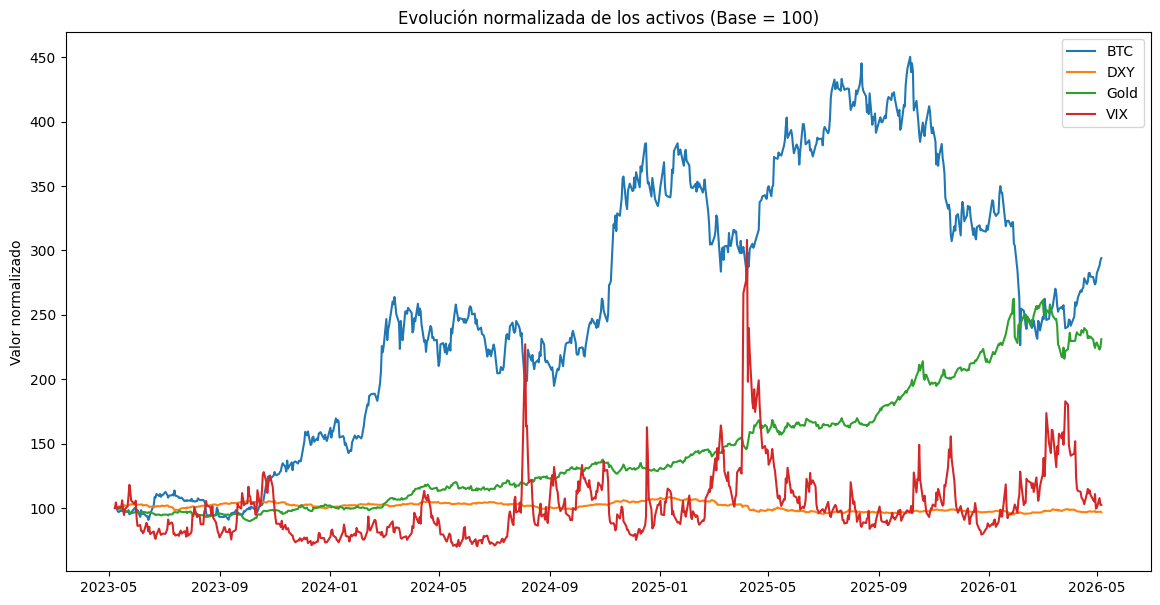

In [14]:
plt.figure(figsize=(14,7))

plt.plot(normalized_df.index, normalized_df["BTC"], label="BTC")
plt.plot(normalized_df.index, normalized_df["DXY"], label="DXY")
plt.plot(normalized_df.index, normalized_df["Gold"], label="Gold")
plt.plot(normalized_df.index, normalized_df["VIX"], label="VIX")

plt.title("Evolución normalizada de los activos (Base = 100)")
plt.ylabel("Valor normalizado")
plt.legend()

plt.show()

### 7.1 Conclusiones

La evolución normalizada de los activos permitió comparar sus trayectorias relativas a lo largo del período analizado independientemente de sus escalas originales.

DXY mostró un comportamiento relativamente estable, con variaciones moderadas respecto de su valor inicial. Oro presentó una tendencia ascendente sostenida y menos volátil, mientras que BTC exhibió ciclos de crecimiento y corrección significativamente más pronunciados.

Por su parte, VIX mostró episodios puntuales de fuertes incrementos, asociados visualmente con algunas de las principales correcciones observadas en BTC.

En conjunto, los resultados evidencian que los cuatro mercados siguieron dinámicas temporales diferenciadas y sugieren que las relaciones entre ellos no permanecieron constantes a lo largo del período analizado.

## 7.2 Correlaciones móviles

Las correlaciones calculadas sobre la totalidad del período proporcionan una visión general de las relaciones entre activos, pero no permiten observar posibles cambios a lo largo del tiempo.

Por este motivo, se estudian correlaciones móviles de 30 días con el objetivo de analizar la evolución temporal de las asociaciones entre distintas variables y evaluar si dichas relaciones permanecieron estables o presentaron variaciones durante el período analizado.

In [15]:
rolling_corr_btc_vix = (
    integrated_df["btc_return"]
    .rolling(window=30)
    .corr(
        integrated_df["vix_return"]
    )
)

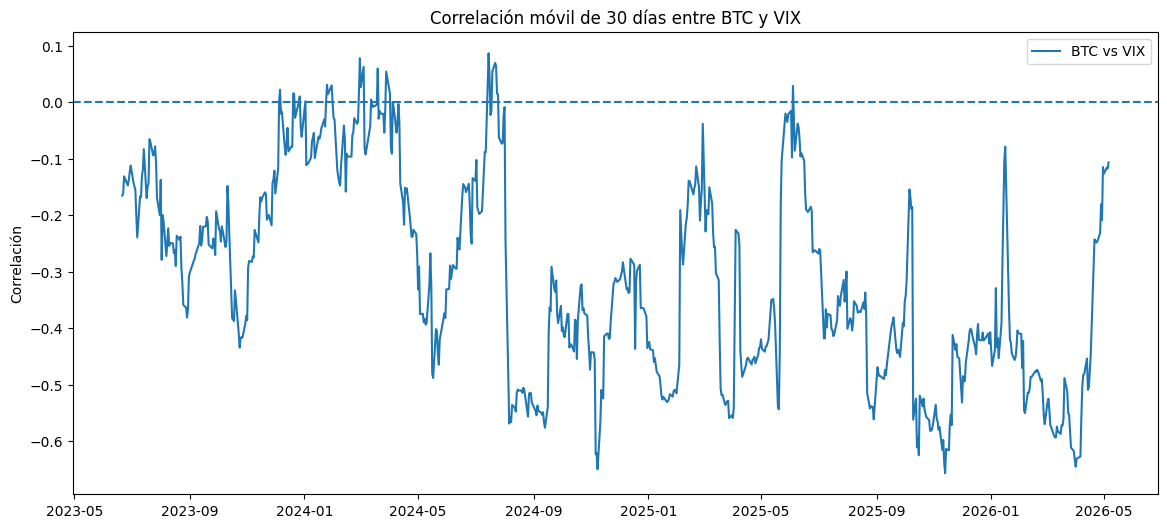

In [16]:
plt.figure(figsize=(14,6))

plt.plot(
    rolling_corr_btc_vix,
    label="BTC vs VIX"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    "Correlación móvil de 30 días entre BTC y VIX"
)

plt.ylabel("Correlación")

plt.legend()

plt.show()

### 7.2 Conclusiones

El análisis de correlaciones móviles permitió observar que la relación entre BTC y VIX no permaneció constante a lo largo del período analizado.

Si bien predominó una asociación negativa, la intensidad de dicha relación presentó variaciones significativas, alternando entre períodos de correlación moderada y fuerte con intervalos prolongados de correlación débil e incluso prácticamente nula.

Estos resultados evidencian que las correlaciones calculadas sobre la totalidad del período representan únicamente una visión promedio y pueden ocultar cambios temporales relevantes en las dinámicas entre activos.

En conjunto, los hallazgos sugieren que la relación entre BTC y VIX es dinámica y dependiente del contexto de mercado, más que una característica fija o permanente.

## 7.3 Correlaciones móviles entre BTC y Oro

Se estudia la evolución temporal de la correlación entre los retornos diarios de BTC y Oro mediante ventanas móviles de 30 días.

El objetivo es analizar la estabilidad de esta relación y evaluar si la asociación observada en el análisis global permaneció constante a lo largo del período estudiado.

In [17]:
rolling_corr_btc_gold = (
    integrated_df["btc_return"]
    .rolling(window=30)
    .corr(
        integrated_df["gold_return"]
    )
)

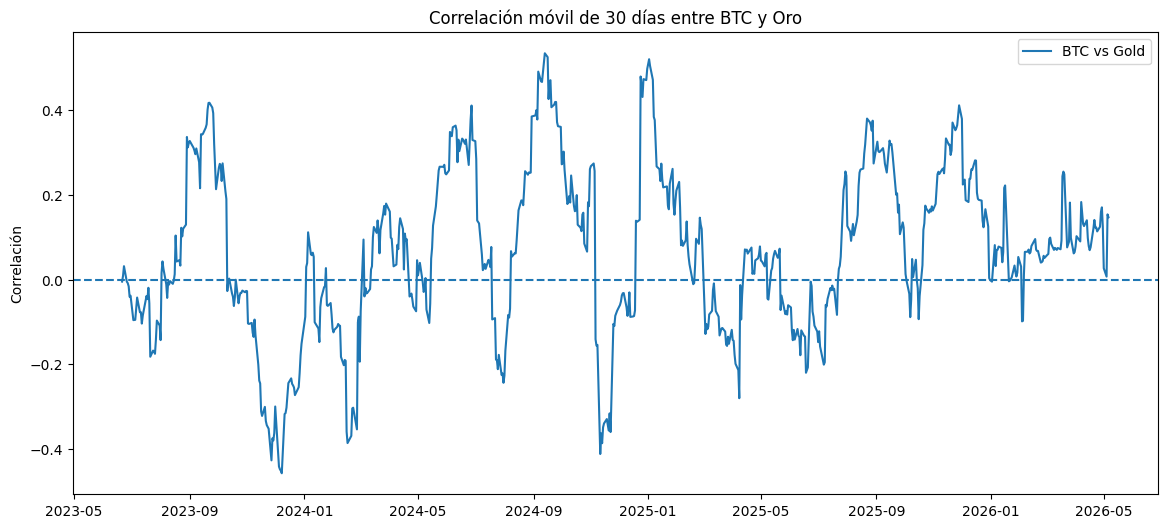

In [18]:
plt.figure(figsize=(14,6))

plt.plot(
    rolling_corr_btc_gold,
    label="BTC vs Gold"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    "Correlación móvil de 30 días entre BTC y Oro"
)

plt.ylabel("Correlación")

plt.legend()

plt.show()

### 7.3 Conclusiones

La relación entre BTC y Oro presentó una mayor variabilidad temporal que la observada entre BTC y VIX.

Las correlaciones móviles mostraron alternancia entre períodos de asociación positiva y negativa, evidenciando que dicha relación no permaneció constante a lo largo del período analizado.

Sin embargo, los intervalos de correlación positiva tendieron a ser más prolongados y frecuentes que los episodios negativos, sugiriendo una asociación positiva predominante aunque no permanente.

Estos resultados indican que las métricas agregadas calculadas sobre períodos extensos pueden ocultar cambios temporales relevantes en las dinámicas entre ambos activos.

## 7.4 Correlaciones móviles entre BTC y DXY

Se analiza la evolución temporal de la correlación entre los retornos diarios de BTC y DXY mediante ventanas móviles de 30 días.

El objetivo es evaluar la estabilidad de la relación entre ambos mercados y determinar si la asociación observada en el análisis global se mantuvo constante a lo largo del período estudiado.

In [19]:
rolling_corr_btc_dxy = (
    integrated_df["btc_return"]
    .rolling(window=30)
    .corr(
        integrated_df["dxy_return"]
    )
)

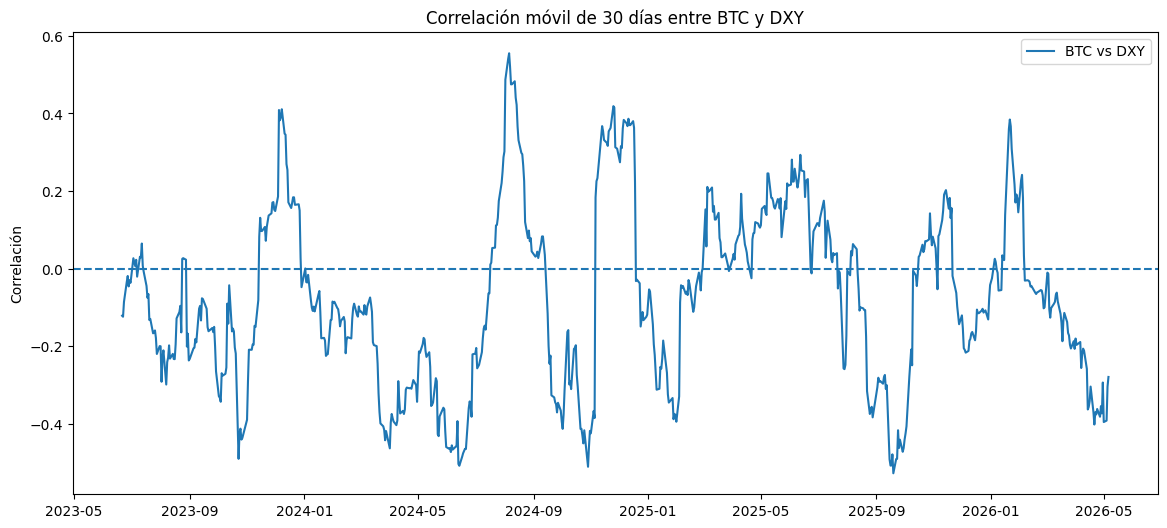

In [20]:
plt.figure(figsize=(14,6))

plt.plot(
    rolling_corr_btc_dxy,
    label="BTC vs DXY"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    "Correlación móvil de 30 días entre BTC y DXY"
)

plt.ylabel("Correlación")

plt.legend()

plt.show()

### 7.4 Conclusiones

La relación entre BTC y DXY presentó una marcada variabilidad temporal, alternando entre períodos de correlación positiva y negativa a lo largo del período analizado.

Si bien predominó una inclinación hacia correlaciones negativas, se observaron intervalos prolongados de asociación positiva, evidenciando que la relación entre ambos mercados no permaneció constante.

Estos resultados sugieren que el bajo valor de correlación global observado para BTC y DXY es consecuencia de la compensación entre distintos regímenes temporales más que de la ausencia de relación entre ambas variables.

En conjunto, los hallazgos indican que la dinámica entre BTC y DXY fue considerablemente más compleja e inestable de lo que sugiere una única métrica agregada calculada sobre la totalidad del período.

# 7.5 Conclusiones generales

El análisis de correlaciones móviles evidenció que las relaciones entre los distintos activos no permanecieron constantes a lo largo del período estudiado.

BTC y VIX mostraron una asociación predominantemente negativa, siendo la relación más estable entre las analizadas, aunque con intervalos prolongados de debilitamiento e incluso episodios de correlación cercana a cero.

BTC y Oro presentaron alternancia entre períodos de correlación positiva y negativa, con predominio de asociaciones positivas más extensas y frecuentes.

Por su parte, BTC y DXY también alternaron entre distintos regímenes temporales, aunque con una inclinación general hacia correlaciones negativas.

En conjunto, los resultados sugieren que las relaciones entre activos financieros son dinámicas y dependientes del contexto, por lo que las correlaciones calculadas sobre períodos extensos representan únicamente una visión promedio de comportamientos considerablemente más complejos e inestables.

# Conclusiones generales

El análisis exploratorio financiero permitió caracterizar el comportamiento de BTC y estudiar sus relaciones con DXY, Oro y VIX durante el período analizado.

Los resultados evidenciaron que BTC presentó una distribución de retornos concentrada alrededor de cero, aunque con episodios puntuales de elevada volatilidad.

El estudio de los eventos extremos y de distintos regímenes de mercado mostró una asociación consistente entre períodos de mayor incertidumbre y una mayor dispersión en los movimientos de BTC, sin que ello implique relaciones causales directas.

Asimismo, la evolución normalizada de los activos y el análisis de correlaciones móviles permitieron observar que las relaciones entre los distintos mercados no permanecieron constantes a lo largo del tiempo.

En conjunto, los resultados sugieren que las asociaciones entre activos financieros son dinámicas y dependientes del contexto, por lo que las métricas agregadas calculadas sobre períodos extensos representan únicamente una visión promedio de comportamientos considerablemente más complejos e inestables.

En consecuencia, los hallazgos obtenidos deben interpretarse como descripciones estadísticas del período analizado y no como reglas determinísticas ni como evidencia de relaciones causales entre los mercados considerados.